In [1]:
import pandas as pd
from tqdm import tqdm
import os
import datetime as dt
import sys
import glob

In [2]:
sys.path.append("/data/workspace/libs/pytools")
db_dir = "/data/workspace/Data/DataBase"
from mfrt.research_tools import DBTool

In [17]:
from mfrt.opt_backtest import OptBacktest
from mfrt.eval_netvalue import EvalNetValue
opt_bt=OptBacktest(db_dir)
eval_NV=EvalNetValue(db_dir)

from mfrt.eval_factor import EvalFactor
eval_F = EvalFactor(db_dir)

check_Barra_list=('BETA', 'MOMENTUM', 'SIZE', 'RESVOL', 'BTOP', 'LIQUIDTY',  'SPRET', 'SIZENL', 'GROWTH', 'LEVERAGE')
def test_factor(factor: pd.DataFrame, 
                start_dt, 
                end_dt, 
                display: bool=False, 
                if_trade_tmr: bool=True, 
                specific_return: bool=True,
                Universe=None,
                return_type='Vwap') -> dict:
    F_res=eval_F.quick_test(factor,start_dt=start_dt,end_dt=end_dt,Group_Num=10,Horizon=10,Return_Type=return_type,
                        Specific_Return=specific_return,Universe=Universe,check_Barra_list=check_Barra_list,
                        extraExp_check_dict=None,if_trade_tmr=if_trade_tmr, display=display)
    
    return F_res

In [18]:
df = pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_baseline/gubapost_stockday_mean_2020_2021_2022_2023.parquet")
# result = df[
#     (df["method"] == "decay_20d_hl10") & 
#     (df["layer"] == 11) &
#     (df["source_split"] == "test")
# ][["trading_date", "symbol", "factor_value"]]

In [19]:
df["sum"] = df["sentiment_mean"] * df["n_posts"]
df

,available_date,symbol,sentiment_mean,n_posts,sum
0,2020-01-02,000001,0.201320,62,12.481812
1,2020-01-02,000002,0.193749,91,17.631165
2,2020-01-02,000004,0.182262,16,2.916199
3,2020-01-02,000005,0.194894,7,1.364258
4,2020-01-02,000006,0.190628,20,3.812561
...,...,...,...,...,...
4405297,2024-01-02,873848,0.232178,2,0.464355
4405298,2024-01-02,873873,0.296143,7,2.072998
4405299,2024-01-02,874018,0.269124,6,1.614746
4405300,2024-01-02,874327,0.242725,5,1.213623


In [20]:
factor_wide = df.set_index(['available_date', 'symbol'])['sum'].unstack()
factor_wide.index.name = 'date' 

In [21]:
# 只保留沪深A股：0/3开头(深) + 6开头(沪)，去掉4/8开头(北交所/新三板)
factor_wide = factor_wide[[c for c in factor_wide.columns if str(c)[0] in '036']]

In [22]:
factor_wide

symbol,000001,000002,000004,000005,000006,000007,000008,000009,000010,000011,...,688787,688788,688789,688793,688798,688799,688800,688819,688981,689009
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,12.481812,17.631165,2.916199,1.364258,3.812561,3.573486,12.679810,59.574646,1.123901,4.239075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,6.590881,23.807251,1.924316,3.711121,3.500122,4.580444,12.102417,78.185974,1.181763,2.200562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,13.419678,33.925598,1.314331,5.424805,1.991028,6.007019,15.118103,77.078491,0.743103,2.181580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,5.838806,12.217407,1.625610,3.234131,3.202393,3.236633,7.014709,86.574829,1.843018,0.946045,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,9.452820,13.236511,0.985962,5.522583,2.126465,6.623657,7.628113,86.033508,0.701172,2.520569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,32.848938,11.836670,1.464844,4.430542,12.500916,1.023499,2.973938,3.022644,1.438721,0.934692,...,1.340576,0.356812,0.208862,0.176636,0.188232,0.666504,1.651611,3.822571,3.877441,6.799927
2023-12-28,22.290161,5.437988,1.189209,1.153809,8.160950,0.194824,2.361450,4.414124,0.301147,0.636475,...,1.136353,0.208618,0.621704,0.619141,1.207825,1.648804,2.081909,0.404053,6.349915,3.524719
2023-12-29,20.673828,13.101257,0.966125,4.129761,3.756775,0.163086,0.929199,6.978516,1.304504,0.934387,...,0.761597,0.571899,0.858887,0.149170,0.370483,0.181641,0.293701,1.779175,7.757446,8.193726


In [23]:
import pandas as pd

# 自动添加后缀：6开头加.SH，其他加.SZ
def add_suffix(col_code):
    if str(col_code).startswith('6'):
        return col_code + '.SH'
    else:
        return col_code + '.SZ'

factor_wide.index.name = 'date' # 确保行索引有名字
factor_wide.columns = [add_suffix(c) for c in factor_wide.columns]

# print(factor_wide.head()) # 检查一下表头是否变成了 000032.SZ

In [ ]:
# pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_baseline/probs_daily/gubapost_probs_20200101.parquet")

In [25]:
# pd.read_parquet("/home/intern_fjq_2026/data/NLP/gubapost/2020/gubapost20200101.parquet")

In [26]:
# 转换为时间戳并升序排列 + 清除 NaT 日期
factor_wide.index = pd.to_datetime(factor_wide.index, errors='coerce')
factor_wide = factor_wide[factor_wide.index.notna()]  # 删掉 'None' 等无效日期行
factor_wide = factor_wide.sort_index()

print(f"日期范围：{factor_wide.index.min().date()} 到 {factor_wide.index.max().date()}")
print(f"列数：{len(factor_wide.columns)}")

日期范围：2020-01-02 到 2024-01-02
列数：5241


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,-8.33%,-0.861,99.1%,87.5%,-61.9%,-4.79,-46.5%,-4.08


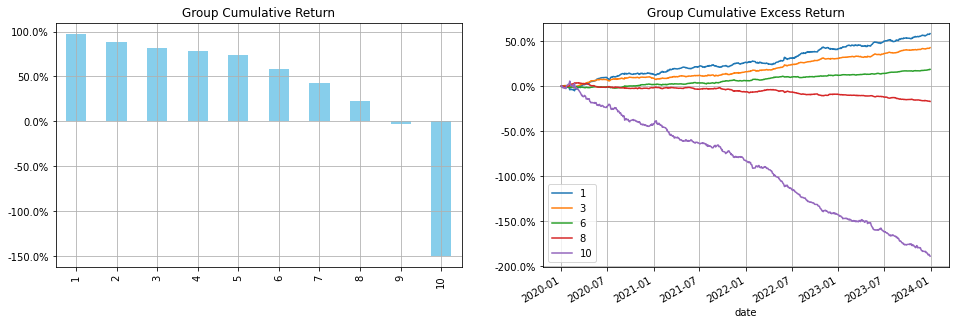

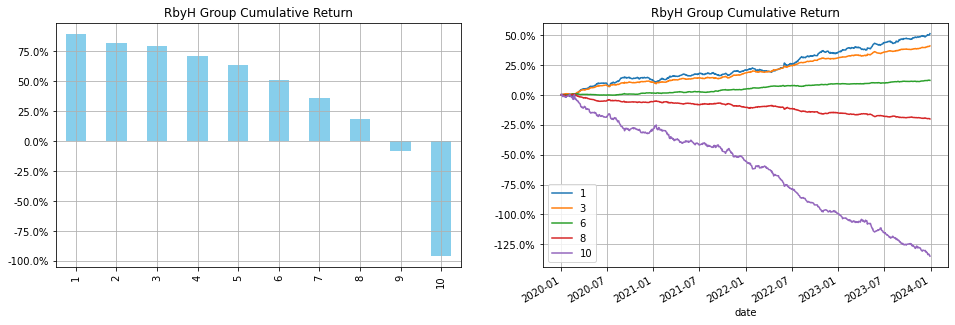

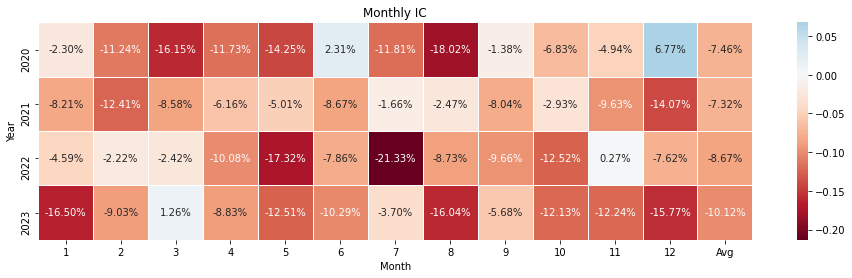

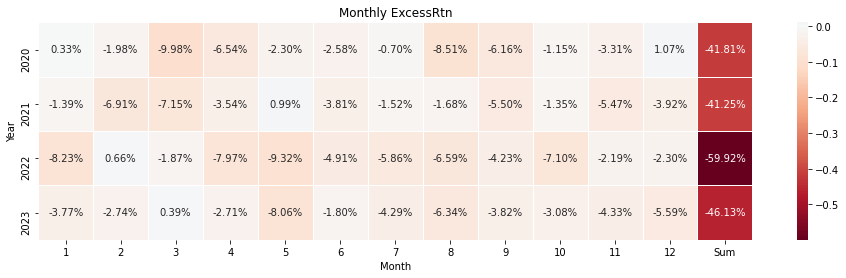

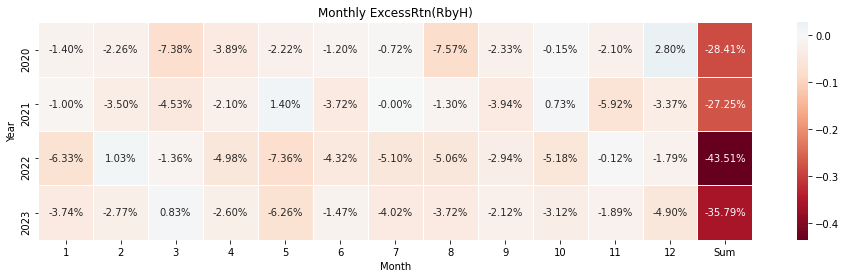

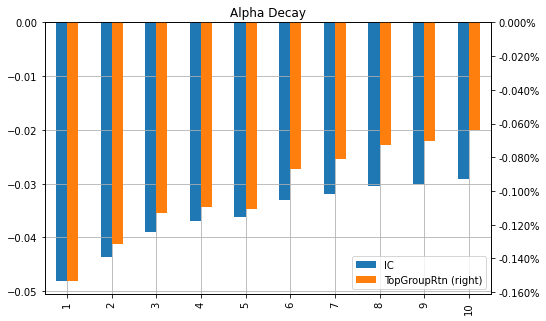

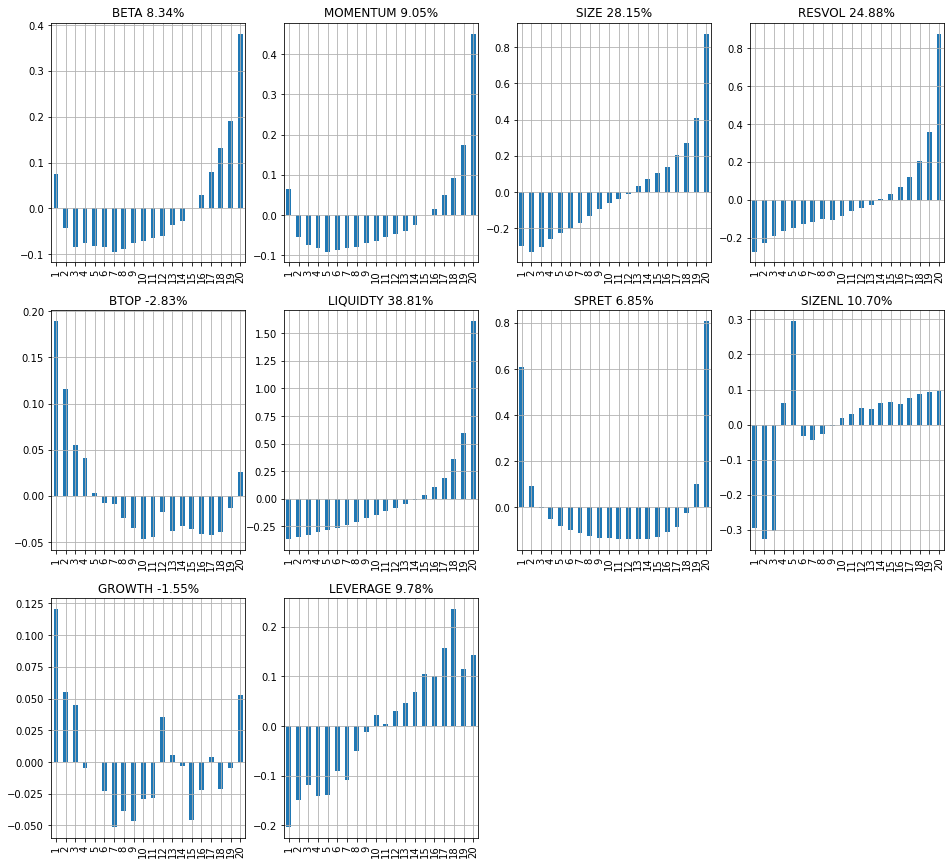

In [28]:
res = test_factor(
            factor_wide.dropna(how="all", axis=0),
            start_dt='2020.01.03',
            end_dt='2023.12.31',
            display=True,
            if_trade_tmr=False,
            specific_return=False,
            return_type="Close",
        )
res